In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines
# from models.gmp import GMP
import matplotlib.pyplot as plt
import numpy as np
import torch
# import pandas as pd

Load data from files

In [ ]:
dataset_path = "datasets/Custom_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.get_gained_signals()

print(f"gain: {container.gain}")



gain: 7.750391483306885


In [ ]:
def prepare_data_for_als(
    x: torch.Tensor,
    y: torch.Tensor,
    M1: int,
    M2: int,
    P: int,
    N: int,
):
    """_summary_

    Args:
        x (torch.Tensor): _description_
        y (torch.Tensor): _description_
        M1 (int): _description_
        M2 (int): _description_
        P (int): _description_
        N (int): _description_
        use_zero_padding (bool, optional): _description_. Defaults to False.

    Returns:
        y_vec, H, M (tuple[Tensor, Tensor, Tensor]): _description_
    """
    
    x = utils.iq_to_complex(x)
    y = utils.iq_to_complex(y)
    
    T = len(x)
    max_delay = max(M1, M2) - 1
    
    start_idx = max_delay
    assert start_idx + N <= T, f"Too short dataset"
    
    # Выход
    y_vec = y[start_idx:start_idx + N]
    
    # Матрица H
    n_indices = torch.arange(N)[:, None]  # (N, 1)
    i_indices = torch.arange(M1)[None, :]  # (1, M1)
    idx_matrix = start_idx + n_indices - i_indices  # (N, M1)
    
    H = x[idx_matrix]  # (N, M1)
    
    # Тензор M
    j_indices = torch.arange(M2)[None, :]
    idx_matrix_j = start_idx + n_indices - j_indices  # (N, M2)
    abs_vals = torch.abs(x[idx_matrix_j])  # (N, M2)
    
    # Возводим в степени
    M = torch.zeros((N, M2, P), dtype=torch.complex64)
    for p in range(P):
        M[:, :, p] = abs_vals ** p
    
    return y_vec, H, M

In [10]:
def ridge_ls(Phi, y, gamma):
    """
    Solve

        min ||y - Phi w||² + gamma ||w||²

    Phi : (N, K)
    y   : (N,)
    """

    K = Phi.shape[1]

    A = torch.matmul(Phi.conj().T, Phi)
    b = torch.matmul(Phi.conj().T, y)

    if gamma > 0:
        A = A + gamma * torch.eye(K, dtype=A.dtype, device=A.device)
        
    w = torch.linalg.solve(A, b)

    return w


def als_identification_of_gmpcp(model, x, y, L, gamma):
    """
    ALS GMP-CP

    Parameters
    ----------
    model : GMPCP
    x, y  : training signals
    L     : number of ALS iterations
    gamma : ridge parameter
    """
    

    R = model.R
    M1 = model.M1
    M2 = model.M2
    P = model.P

    N = len(x) - max(M1, M2) + 1

    y_vec, H, M = prepare_data_for_als(x,
                                       y,
                                       M1,
                                       M2,
                                       P,
                                       N,
                                    )
    
    A = model.a.clone()
    B = model.b.clone()
    C = model.c.clone()
    
    for _ in range(L):
        
        # A

        MBC = torch.einsum('njp,jr,pr->nr', M, B, C)
        
        D = H[:, :, None] * MBC[:, None, :]
        D = D.reshape(N, M1 * R)
        
        a = ridge_ls(D, y_vec, gamma)
        A = a.reshape(M1, R)
        
        # B
        
        HA = H @ A

        MC = torch.einsum('njp,pr->njr', M, C)

        E = MC * HA[:, None, :]
        E = E.reshape(N, M2 * R)

        b = ridge_ls(E, y_vec, gamma)
        B = b.reshape(M2, R)
        
        # C
        
        HA = H @ A

        MB = torch.einsum('njp,jr->npr', M, B)

        F = MB * HA[:, None, :]
        F = F.reshape(N, P * R)

        c = ridge_ls(F, y_vec, gamma)
        C = c.reshape(P, R)

    model.set_parameters(A, B, C)

    return model
        

In [11]:
from modules import utils
from models.base_model import BaseModel


class GMPCP(torch.nn.Module, BaseModel):
    def __init__(self, R, M1, M2, P, model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.R, self.M1, self.M2, self.P = R, M1, M2, P
        
        self.register_buffer('a', 0.1 * torch.randn(M1, R, dtype=torch.complex64))
        self.register_buffer('b', 0.1 * torch.randn(M2, R, dtype=torch.complex64))
        self.register_buffer('c', 0.1 * torch.randn(P, R, dtype=torch.complex64))
        
        self.max_delay = max(self.M1, self.M2) - 1
        self.register_buffer('M1_arange', torch.arange(self.M1))
        self.register_buffer('M2_arange', torch.arange(self.M2))
        self.register_buffer('powers_arange', torch.arange(self.P))
    
    def _get_filename(self):
        return (f"{self.model_name}_{self.class_name}_"
                f"R({self.R})_M1({self.M1})_"
                f"M2({self.M2})_P({self.P}).pt")
    
    def set_parameters(self, a_new, b_new, c_new):
        """Update parameters"""
        self.a.copy_(a_new)
        self.b.copy_(b_new)
        self.c.copy_(c_new)
    
    def forward(self, x):
        """
        x: (T,) — комплексный входной сигнал
        returns: (T,) — комплексный выходной сигнал
        """
        T = x.shape[0]
        T_cut = T - self.max_delay
        
        y = torch.zeros(T_cut, dtype=torch.complex64, device=x.device)
        
        for n in range(T_cut):
            t = n + self.max_delay

            delays_m1 = x[t - self.M1_arange]
            sum_i = torch.matmul(self.a.T, delays_m1)
            
            delays = x[t - self.M2_arange]
            abs_delays = torch.abs(delays)
            abs_powers = (abs_delays[:, None] ** self.powers_arange[None, :]).to(torch.complex64)
            
            bc = self.b[:, None, :] * self.c[None, :, :]
            sum_jp = torch.einsum('mpr,mp->r', bc, abs_powers,)
            
            y[n] = torch.sum(sum_i * sum_jp)
        
        return y

Algorithm 3 ALS algorithm for the identification of GMP-CP model

In [20]:
R=3
M1=11
M2=10
P=8
N=4096

gamma = 1e-3
L = 30
# torch.manual_seed(42)

model = GMPCP(R=R, M1=M1, M2=M2, P=P, model_name='pa')

In [21]:
model = als_identification_of_gmpcp(model,
                                    x=container.train_input,
                                    y=container.train_output,
                                    L=L,
                                    gamma=gamma)

# model.save_weights()

In [22]:
x = utils.iq_to_complex(container.val_input_orig)

with torch.no_grad():
    y_pred = model(x)


delay = max(model.M1, model.M2) - 1

y_true = utils.iq_to_complex(container.val_output[delay:])

gmpcp_nmse = metrics.compute_nmse(y_pred, y_true)
print(F"NMSE: {gmpcp_nmse:.2f} dB")

gmpcp_acepr = metrics.compute_acepr(
    measured=y_pred,
    predicted=y_true,
    fs=container.input_signal_fs,
    main_bandwidth=container.bw_main_ch,
    adjacent_bandwidth=container.bw_main_ch,
    channel_offset=container.bw_main_ch,
    nperseg=container.nperseg
)

print(f"ACEPR: {gmpcp_acepr:.2f} dB")

NMSE: -48.77 dB
ACEPR: -54.16 dB


c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


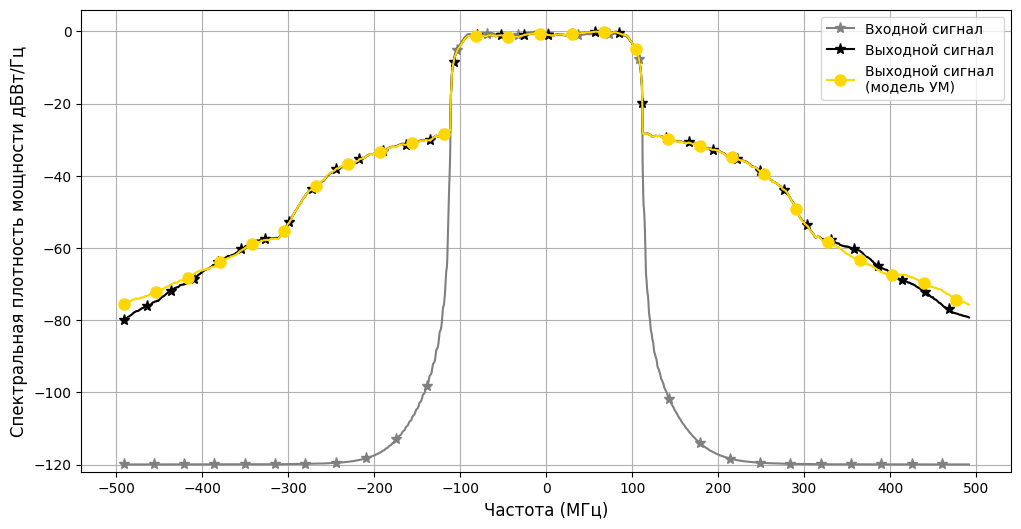

In [15]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output[delay:], container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_pred, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-122)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()
